# Final Project Review

## Music Genre Classification with CNNs and Audio-Based Song Recommendation

This notebook summarizes the full project development, the main results, and the most important insights gained throughout the project.

## Motivation

The goal of this project was not only to build an accurate music genre classifier, but also to understand the complete machine learning workflow for audio data.

Starting from raw audio signals, the project gradually explored feature extraction, classical machine learning, deep learning, and content-based recommendation systems.

Each notebook introduced one new concept while building upon the previous work, resulting in a complete end-to-end audio machine learning pipeline.

## Project Overview

The goal of this project was to build a machine learning system for music genre classification and extend it into an audio-based song recommendation system.

The project started with basic audio exploration and gradually developed into a complete pipeline:

Audio files → Feature extraction → Classical machine learning → CNN classification → CNN-based recommendation

The final system uses a convolutional neural network trained on Mel-spectrograms to classify music genres and reuse learned feature representations for content-based music recommendation.

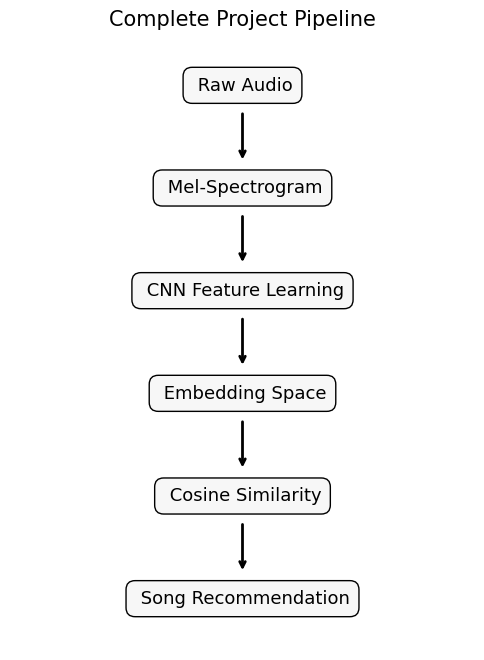

In [8]:
import matplotlib.pyplot as plt

steps = [
    " Raw Audio",
    " Mel-Spectrogram",
    " CNN Feature Learning",
    " Embedding Space",
    " Cosine Similarity",
    " Song Recommendation"
]

fig, ax = plt.subplots(figsize=(6, 8))

ax.set_xlim(0, 1)
ax.set_ylim(0, len(steps))
ax.axis("off")

for i, step in enumerate(reversed(steps)):
    y = i + 0.5

    ax.text(
        0.5,
        y,
        step,
        ha="center",
        va="center",
        fontsize=13,
        bbox=dict(
            boxstyle="round,pad=0.5",
            fc="#f7f7f7",
            ec="black"
        )
    )

    if i < len(steps)-1:
        ax.annotate(
            "",
            xy=(0.5, y+0.25),
            xytext=(0.5, y+0.75),
            arrowprops=dict(arrowstyle="->", lw=2)
        )

plt.title("Complete Project Pipeline", fontsize=15)
plt.show()

## Project Timeline

| Week | Notebook | Main Focus |
|---:|---|---|
| 1 | Audio Basics | Loading audio, waveform, spectrogram |
| 2 | Mel-Spectrograms | Mel representation for audio ML |
| 3 | Dataset Preparation | GTZAN dataset pipeline |
| 4 | Baseline Model | MFCC + Random Forest |
| 5 | Model Evaluation | Confusion matrix and error analysis |
| 6 | First CNN | Mel-spectrogram CNN classifier |
| 7 | Model Comparison | Random Forest vs CNN |
| 8 | MFCC Recommendation | First content-based recommendation system |
| 9 | Feature Representation Analysis | MFCC, Mel, cosine similarity, PCA |
| 10 | CNN Optimization | Validation, early stopping, overfitting |
| 11 | Feature Fusion Classifier | MFCC + Chroma + spectral + rhythm features |
| 12 | Final CNN Classifier | Full GTZAN CNN with augmentation |
| 13 | CNN-Based Recommendation | Recommendation using learned CNN embeddings |

## Biggest Technical Milestones

Throughout the project, several milestones significantly improved the system:

- First successful audio visualization
- First Random Forest baseline
- First CNN classifier
- Optimized CNN training pipeline
- Feature Fusion
- CNN embedding recommendation system

Each milestone solved one limitation of the previous approach.

## Model Results

| Model | Input Representation | Dataset Scope | Accuracy |
|---|---|---:|---:|
| MFCC Random Forest | 13 MFCC features | 4 genres | ~79% |
| First CNN | Mel-spectrograms | 4 genres | ~85% |
| Optimized CNN | Mel-spectrograms | 4 genres | ~80% |
| Feature Fusion Random Forest | MFCC + Chroma + spectral + rhythm features | 4 genres | ~90% |
| Final CNN | Mel-spectrograms | 10 genres | ~78% |

The Feature Fusion Random Forest achieved the highest accuracy on the reduced four-genre setup.

The Final CNN was selected as the final model because it was trained on the full GTZAN dataset and learns reusable feature representations directly from Mel-spectrograms.

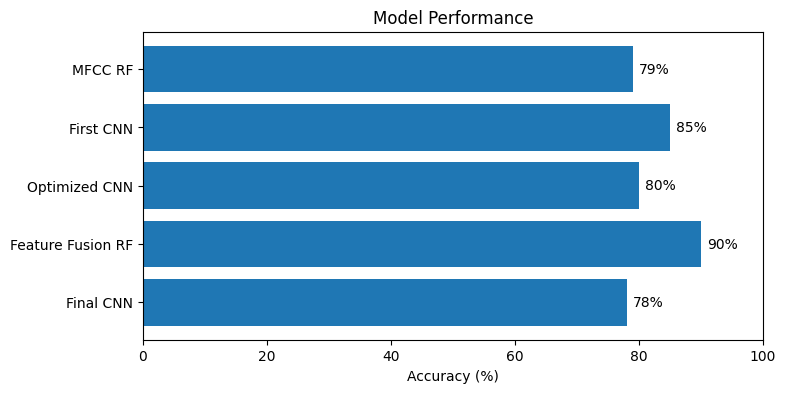

In [10]:
models = [
    "Final CNN",
    "Feature Fusion RF",
    "Optimized CNN",
    "First CNN",
    "MFCC RF"
]

acc = [78,90,80,85,79]

plt.figure(figsize=(8,4))

bars = plt.barh(models,acc)

plt.xlim(0,100)

for bar,val in zip(bars,acc):

    plt.text(
        val+1,
        bar.get_y()+bar.get_height()/2,
        f"{val}%",
        va="center"
    )

plt.xlabel("Accuracy (%)")
plt.title("Model Performance")
plt.show()

The final CNN was trained on all ten GTZAN genres, while earlier models used reduced four-genre subsets. Therefore, the results are not directly comparable, but they show the development of the project.

## Key Insight 1: Audio Representation Matters

Different audio representations serve different purposes.

- Waveforms show the raw signal.
- Spectrograms reveal frequency content over time.
- Mel-spectrograms provide a perceptually meaningful time-frequency representation.
- MFCCs compactly summarize timbral characteristics.
- Feature fusion combines multiple musical dimensions.

A major result of this project is that the choice of representation strongly affects model performance and interpretability.

## Key Insight 2: Handcrafted Features Are Still Powerful

The Feature Fusion Random Forest achieved very strong results by combining manually engineered descriptors:

- MFCCs for timbre
- Chroma and Tonnetz for harmony
- Spectral Contrast, Centroid, Bandwidth, and Rolloff for spectral shape
- Zero Crossing Rate for noisiness and transients
- Tempo for rhythm

This showed that classical machine learning can perform extremely well when meaningful features are carefully selected.

## Key Insight 3: CNNs Learn Their Own Representations

Unlike the Random Forest models, the CNN does not rely on manually selected audio descriptors.

Instead, it receives Mel-spectrograms and learns useful internal representations automatically.

This is important because these learned representations can be reused beyond classification, for example in the final recommendation system.

## Unexpected Findings

Several observations were unexpected during the project:

- MFCC similarity did not always correspond to genre labels.
- Feature Fusion significantly improved classical machine learning performance.
- CNN embeddings could successfully be reused for recommendation.
- Better training procedures were often more important than deeper networks.

These findings shaped the direction of later experiments.

## Why the Final Model Is a CNN

The Feature Fusion Random Forest achieved the highest accuracy in the reduced four-genre experiment.

However, the final CNN was selected as the final model for three reasons:

1. It was trained on the complete ten-genre GTZAN dataset.
2. It learns feature representations automatically from Mel-spectrograms.
3. Its internal embeddings can be reused for content-based music recommendation.

Therefore, the CNN is not only a classifier but also the foundation for the recommendation stage of the project.

## Model Selection Logic

The final model was not selected solely based on accuracy.  
The Feature Fusion Random Forest achieved the strongest classical classification result, but the CNN was selected as the final model because its learned representations can also be reused for recommendation.

Feature Fusion RF

✔ höchste Accuracy

✘ keine Embeddings

✘ keine Recommendation

---------------------------

Final CNN

✔ automatische Features

✔ Embeddings

✔ Recommendation

✔ End-to-End

## Recommendation System

The final stage of the project reused the trained CNN as a feature extractor.

Instead of using the final genre prediction, embeddings from the CNN were extracted and compared using cosine similarity.

This enabled content-based song recommendation:

Song → Mel-spectrogram → CNN embedding → Cosine similarity → Recommended songs

The recommendation examples showed musically plausible results. Songs from distinctive genres were often recommended within the same genre, while related genres such as Rock and Metal or Blues and Jazz showed meaningful overlap.

## Evolution of Ideas

Several assumptions made early in the project changed over time.

Initially, MFCCs appeared to be the obvious choice for audio analysis because they are compact and computationally efficient.

Later experiments showed that Mel-spectrograms provide richer information for deep learning models.

Finally, CNN embeddings demonstrated that learned representations can be reused beyond classification for recommendation tasks.

This evolution illustrates how experimental evidence guided the design decisions throughout the project.

## Key Lessons Learned

The project showed that genre classification and recommendation require more than simply training one model.  
The most important insights concern representation choice, model evaluation, and the reuse of learned embeddings.

① Audio Representation matters

↓

② Feature Engineering is powerful

↓

③ CNNs learn reusable features

↓

④ Data Augmentation improves generalization

↓

⑤ Learned embeddings enable recommendation

## Challenges

Several practical and conceptual challenges appeared during the project:

- Handling corrupted GTZAN files
- Understanding different audio representations
- Avoiding overfitting in CNN training
- Comparing models trained on different dataset sizes
- Interpreting feature importance
- Deciding between handcrafted and learned representations

These challenges helped shape the final project structure and led to more robust experiments.

## Limitations

Although the project produced a complete working system, several limitations remain:

- GTZAN is relatively small and contains known labeling and duplication issues.
- The CNN was trained without GPU acceleration.
- The recommendation system was evaluated mostly qualitatively.
- Genre labels are simplified and do not fully capture musical style.
- The model only uses audio content and does not consider user preferences.

These limitations should be considered when interpreting the results.

The recommendation system was evaluated qualitatively through listening tests.

A more rigorous evaluation using user studies or ranking metrics would provide stronger evidence for recommendation quality.

## Future Work

Possible future improvements include:

- Training on larger and cleaner music datasets
- Using data augmentation more extensively
- Testing transformer-based audio models
- Applying contrastive learning for recommendation
- Comparing MFCC-based and CNN-based recommendation quantitatively
- Adding user preference data
- Integrating external metadata such as artist, year, or mood
- Deploying the model in a small interactive web application

## Final Conclusion

This project developed a complete audio machine learning pipeline from basic audio exploration to CNN-based song recommendation.

The project showed that handcrafted audio features can provide very strong classification performance, especially when multiple musical dimensions are combined.

At the same time, the final CNN demonstrated the strength of learned representations. It classified all ten GTZAN genres and produced embeddings that could be reused for content-based music recommendation.

The final system therefore combines music genre classification and audio-based recommendation into one coherent machine learning project.

## Final Takeaway

This project demonstrates that successful machine learning systems are rarely created through a single breakthrough.

Instead, they emerge from many small, iterative improvements.

From simple waveform visualizations to CNN-based recommendation systems, each notebook contributed one essential piece to the final pipeline.

The most important lesson was not simply achieving higher accuracy, but understanding why different representations, models, and training strategies lead to different outcomes.

This understanding forms the foundation for future work in audio machine learning.